# Generador de Datos Sintéticos para Riesgo Crediticio
### En este notebook, construiremos un dataset que simula el comportamiento de clientes bancarios. El objetivo es crear una base de datos con una tasa de morosidad controlada y variables que sigan distribuciones estadísticas realistas (como ingresos log-normales y edades normales).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerias importadas correctamente.")

# Definimos la semilla para que los resultados sean iguales siempre
random_state = 42
rng = np.random.default_rng(random_state)


Librerias importadas correctamente.


## 1. Proporción de la población 
### Definimos cuántos clientes serán "buenos" (cumplen con sus pagos) y cuántos "malos" (entran en mora). Usaremos una proporción del 7% para los malos, lo cual es común en carteras de crédito reales.

In [3]:
n_samples = 150_000
n_bad = int(n_samples * 0.07)
n_good = n_samples - n_bad

print(f"Total: {n_samples} | Buenos: {n_good} | Malos: {n_bad}")

Total: 150000 | Buenos: 139500 | Malos: 10500


## 2. Modelado de las Variables Críticas

### Para que el modelo sea útil, las variables deben comportarse de forma distinta según el tipo de cliente:

### -Edad: Seguira una distribución Normal. Los clientes buenos suelen tener un promedio de edad ligeramente mayor.

### -Ingresos: Usaremos una distribución Log-Normal, ya que los ingresos no son simétricos (pocas personas ganan mucho).

### -Atrasos: Usaremos una distribución de Poisson, ideal para contar eventos independientes (cuántas veces se atrasó).

In [4]:
def _make_group(n, is_bad):
        """Genera features con distribuciones distintas por segmento."""
        inc_mu = 3_800 if is_bad else 6_200          # ingreso mensual USD
        age_mu = 40    if is_bad else 47

        utilization = rng.beta(2 if is_bad else 0.8, 2, n).clip(0, 1)
        age         = rng.normal(age_mu, 9, n).clip(18, 90).astype(int)
        income      = rng.lognormal(np.log(inc_mu), 0.6, n)
        income      = np.where(rng.random(n) < 0.02, np.nan, income)  

        debt_ratio  = rng.beta(1.5 if is_bad else 0.5, 3, n).clip(0, 1)

        past30_59   = rng.poisson(1.5 if is_bad else 0.1, n)
        past60_89   = rng.poisson(0.8 if is_bad else 0.05, n)
        past90plus  = rng.poisson(0.5 if is_bad else 0.02, n)

        open_lines  = rng.poisson(8, n).clip(0, 40)
        real_estate = rng.poisson(1 if is_bad else 1.5, n).clip(0, 10)
        dependents  = rng.poisson(1.0, n).clip(0, 10)
        dependents  = np.where(rng.random(n) < 0.025, np.nan, dependents) 


## 3. Ensayo de lógica
### Aquí ensayamos la lógica de los ingresos antes de crear la función completa. Los "malos" tienen ingresos más bajos y una distribución más hacia la izquierda.

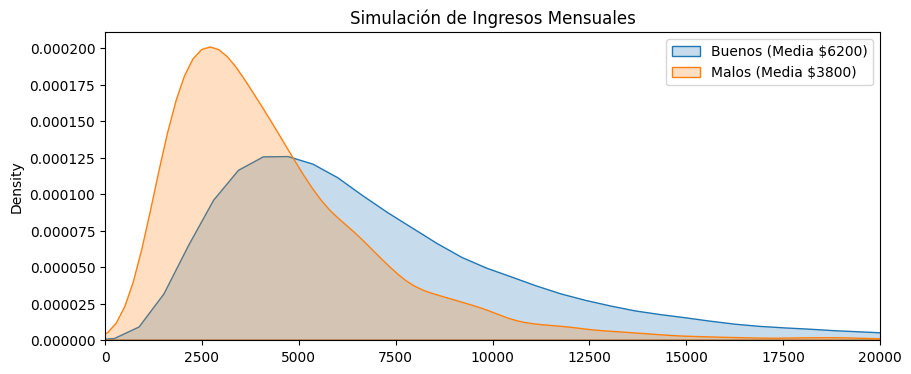

In [5]:
# Simulación rápida
inc_good = rng.lognormal(np.log(6200), 0.6, n_good)
inc_bad = rng.lognormal(np.log(3800), 0.6, n_bad)

plt.figure(figsize=(10, 4))
sns.kdeplot(inc_good, label="Buenos (Media $6200)", fill=True)
sns.kdeplot(inc_bad, label="Malos (Media $3800)", fill=True)
plt.xlim(0, 20000)
plt.title("Simulación de Ingresos Mensuales")
plt.legend()
plt.show()

## 4. Empaquetado final

### Ahora empaquetamos todo en la función final. Esta función utiliza pd.concat para unir ambos grupos y luego hace un shuffle (mezcla) para que el orden sea aleatorio.

In [7]:
def generate_credit_data(n_samples: int = 150_000, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    # Clientes buenos (~93%) y malos (~7%) — distribución real del dataset
    n_bad  = int(n_samples * 0.0700)
    n_good = n_samples - n_bad

    def _make_group(n, is_bad):
        """Genera features con distribuciones distintas por segmento."""
        inc_mu = 3_800 if is_bad else 6_200          # ingreso mensual USD
        age_mu = 40    if is_bad else 47

        utilization = rng.beta(2 if is_bad else 0.8, 2, n).clip(0, 1)
        age         = rng.normal(age_mu, 9, n).clip(18, 90).astype(int)
        income      = rng.lognormal(np.log(inc_mu), 0.6, n)
        income      = np.where(rng.random(n) < 0.02, np.nan, income)   

        debt_ratio  = rng.beta(1.5 if is_bad else 0.5, 3, n).clip(0, 1)

        past30_59   = rng.poisson(1.5 if is_bad else 0.1, n)
        past60_89   = rng.poisson(0.8 if is_bad else 0.05, n)
        past90plus  = rng.poisson(0.5 if is_bad else 0.02, n)

        open_lines  = rng.poisson(8, n).clip(0, 40)
        real_estate = rng.poisson(1 if is_bad else 1.5, n).clip(0, 10)
        dependents  = rng.poisson(1.0, n).clip(0, 10)
        dependents  = np.where(rng.random(n) < 0.025, np.nan, dependents) 

        return pd.DataFrame({
            "RevolvingUtilizationOfUnsecuredLines": utilization,
            "age": age,
            "NumberOfTime30-59DaysPastDueNotWorse": past30_59,
            "DebtRatio": debt_ratio,
            "MonthlyIncome": income,
            "NumberOfOpenCreditLinesAndLoans": open_lines,
            "NumberOfTimes90DaysLate": past90plus,
            "NumberRealEstateLoansOrLines": real_estate,
            "NumberOfTime60-89DaysPastDueNotWorse": past60_89,
            "NumberOfDependents": dependents,
            "SeriousDlqin2yrs": int(is_bad),
        })

    df = pd.concat([_make_group(n_good, False), _make_group(n_bad, True)], ignore_index=True)
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df


if __name__ == "__main__":
    df = generate_credit_data()
    df.to_csv("data/credit_data.csv", index=False)
    print(f"Dataset generado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"Tasa de morosidad: {df['SeriousDlqin2yrs'].mean():.2%}")

Dataset generado: 150,000 filas x 11 columnas
Tasa de morosidad: 7.00%


## 5. Verificación

### Ejecutamos la función y verificamos la calidad de los datos generados.

In [8]:
df = generate_credit_data()

# Verificamos valores nulos generados intencionalmente
print("Valores nulos por columna:")
print(df.isnull().sum())

# Mostramos el balance del target
print(f"\nTasa de morosidad real: {df['SeriousDlqin2yrs'].mean():.2%}")

df.head()

Valores nulos por columna:
RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                           3026
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                      3673
SeriousDlqin2yrs                           0
dtype: int64

Tasa de morosidad real: 7.00%


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
0,0.180323,52,0,0.560283,33639.219784,6,0,4,0,3.0,0
1,0.142926,43,0,0.356668,NaN,11,0,2,0,1.0,0
2,0.177569,50,0,0.255982,9774.766236,13,0,2,0,NaN,0
3,0.441123,36,1,0.362655,2495.959520,6,1,0,1,2.0,1
4,0.523671,26,0,0.337566,3628.188934,6,0,2,1,1.0,1
